# Домашка. MatrixVisualizer (7 баллов)

Кто не понимает контекст, смотрим первый семинар по интерпретации :)
Для выполнения задания РЕКОМЕНДУЕТСЯ пользоваться LLM (с умом!),
    а также посмотреть семинар по bokeh и (дополнительно) HDBSCAN.

Вам нужно написать класс, который визуализирует произвольную матрицу / датафрейм чисел в формате интерактивной heatmap с помощью библиотеки bokeh. Для удобства представим, что на вход приходит матрица размера N_features x K, то есть, своего рода эмбеддинги признаков (например, полученные путем агрегирования инфы из `model.trees_to_dataframe()`). Сами решите, в каком формате вы подаете сами данные (np.ndarray + отдельно лейблы осей Х, Y или же датафрейм или же что угодно еще). Класс нужно реализовать универсальным образом, то есть не затачиваясь конкретно на то, что вам придут именно признаки, однако в формулировке задания в целях удобочитаемости я буду писать "признаки", где имею в виду строки или же подписи к оси Y. 

Итак, вам нужно визуализировать матрицу согласно следующим требованиям:
- heatmap-style визуализация (см. семинар)
- Если N_features (в общем случае кол-во строк матрицы) велико, то в первоначальной картинке "признаков" не видно.
      Они должны становиться видны при достаточно крупном зуме (решайте сами каком), чтобы картинка была читаема.
      Соответственно, должен быть реализован механизм зума (через любой инструмент)
- График должен быть раскрашен с помощью QuantileTransformer'a:
```python
a = np.array([1, 2, 0, 4, 10, -1])
b = QT(a, num_quantiles=6)
# b = np.array([0.4, 0.2, 0.6, 0.8, 1., 0.])
```
    (то есть цвета для раскраски формируются по b, а не по a)

- Палитра 'coolwarm'. Должен быть colorbar + числовые подписи к его цветам (хотя бы несколько основных)
- Где-нибудь рядышком должен быть виджет выпадающего окна, в котором можно выбрать, "по какой оси" делать покраску:
    - по строкам (то есть у каждого "признака" свои квантили; вкл. по умолчанию)
    - по столбцам
    - глобальная (то есть, квантиль 1. получает максимальное число в матрице, а 0. -- минимальное)<br>
- После выбора "оси", раскраска должна перерисовываться на лету
- Ваши "признаки" должны быть отсортированы согласно кластеризации HDBSCAN (кормим на вход эмбеддинги "признаков",
      желательно сразу в построчной квантильной форме, которую считали для покраски по умолчанию).
      Не нужно строить иерархии, можно просто отсортировать по номеру кластера (не забудьте отсортировать и "подписи").
      Нам важно только чтобы похожие "признаки" были рядом. Расположение кластеров относительно друг друга не имеет значения
- Должна быть возможность "выбрать" какие-то признаки (например, инструментом Tap / Выделением),
      после чего они должны появляться в отдельном текстовом окошечке с накинутыми на них кавычками
      и кнопкой Копировать рядом для удобства.
      Это может быть полезно, например, для того, чтобы быстро выкинуть из выборки "признаки", которые вам кажутся
      неудачными при анализе данной матрицы.
- Весь интерактив с виджетами должен быть реализован строго БЕЗ js-коллбэков (можно только для копирования текста в буфер),
    только python-коллбэки с поднятием локального
    bokeh server в ноутбуке (конструкция def app(doc): ... + show(app), см. семинар по bokeh, HDBSCAN)
- Придумайте удобный вам формат принятия данных на вход для того чтобы подписать оси X, Y, (labels, tick_labels)
- Попросите LLM сгенерировать какую-нибудь матрицу, которая наглядно бы демонстрировала, что вы справились с заданием,
      и запустите на ней вашу визуализацию

**! Если ваша визуализация не заработает (буду запускать локально с вашими версиями библиотек; обновитесь по возможности до последних версий hdbscan, bokeh), будет 0 баллов, так что перед отправкой убедитесь, что оно работает как надо**

Ниже дан ориентир: (там выполнены не все пункты, выполняйте свои)

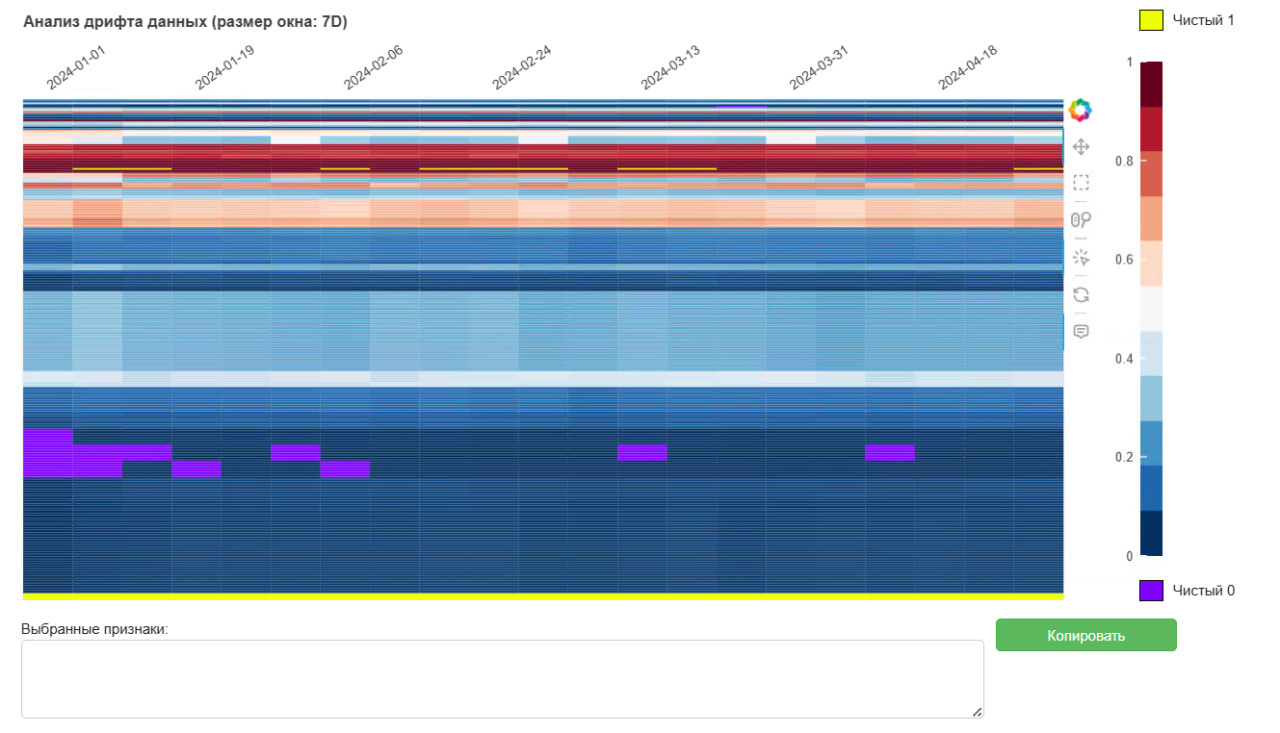

In [1]:
from IPython.display import Image

Image('ex_1.jpg')

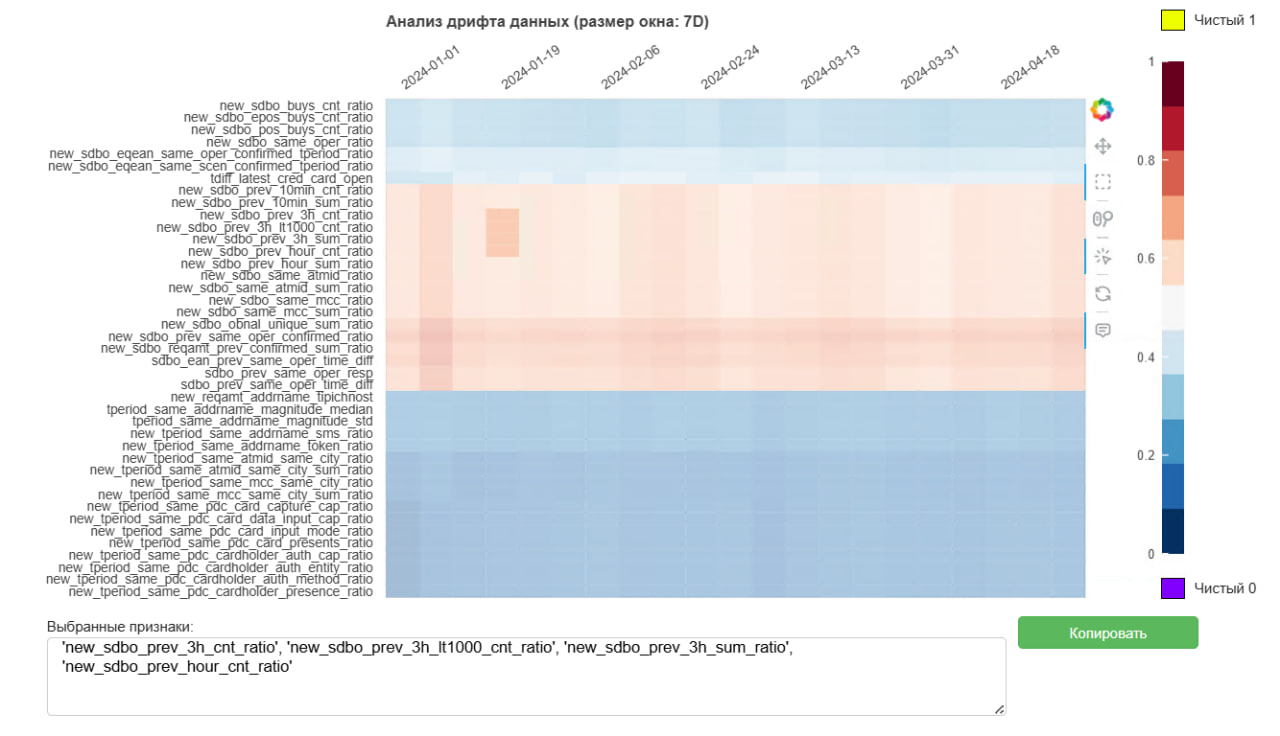

In [2]:
# зум, выделение признаков, появление признаков
Image('ex_2.jpg')

## Удачи!

In [ ]:
# your code here